In [22]:
import pandas as pd
import random
import cv2
import os 
import numpy as np
from matplotlib import pyplot as plt 
from matplotlib.backends.backend_pdf import PdfPages
import re
import tensorflow as tf 
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from utils_real_test import create_model_info_dict, select_model_and_paths, get_test_set, make_inference, add_tp_fp_tn_fn_class, add_gt_pred_pred_binary
from utils_real_test import prepare_visual_sequences
from utils_dataset import prepare_sequences2

from utils_model import build_teacher_model
from utils_real_test import imshow_all_series, imshow_series
from tensorflow.keras.models import load_model


# Parameters to modify 

In [3]:
test_size = 15000
sequence_length = 5 
data_dir = ".."
csv_data_dir = "/Users/marguerite/workspace_DS/pyronear_CNN/" 
all_data_csv_path = "2_preprocessed_sequences_with_interpolation_v0.csv"

# model_name = "model15000"
# model_name = "model12000_gamma3"
# model_name =  "model12000_recall"
# model_name = "model12000_recall_firstalpha2"
# model_name = "model12000_recall_firstalpha10"
# model_name = "model12000_recall_firstalpha10_reduce_lr_2"
# model_name = "model12000_recall_firstalpha10_reduce_lr_3"
# model_name = "model12000_recall_firstalpha10_reduce_lr_4"
# model_name = "model12000_recall_firstalpha10_reduce_lr_4_bbox"
model_name = "model12000_recall_firstalpha10_4_bbox2"


# Update the lists if there is a new model to evaluate: they are needed to build a dictionary with all csv paths for a given model


In [4]:
model_dir_list=[
"/Users/marguerite/workspace_DS/pyronear_CNN/model15000",
"/Users/marguerite/workspace_DS/pyronear_CNN/model12000_gamma3",
"/Users/marguerite/workspace_DS/pyronear_CNN/model12000_recall",
"/Users/marguerite/workspace_DS/pyronear_CNN/model12000_recall_firstalpha2",
"/Users/marguerite/workspace_DS/pyronear_CNN/model12000_recall_firstalpha10",
"/Users/marguerite/workspace_DS/pyronear_CNN/model12000_recall_firstalpha10_reduce_lr_2",
"/Users/marguerite/workspace_DS/pyronear_CNN/model12000_recall_firstalpha10_reduce_lr_3",
"/Users/marguerite/workspace_DS/pyronear_CNN/model12000_recall_firstalpha10_reduce_lr_4", 
"/Users/marguerite/workspace_DS/pyronear_CNN/model12000_recall_firstalpha10_reduce_lr_4_bbox", 
"/Users/marguerite/workspace_DS/pyronear_CNN/model12000_recall_firstalpha10_4_bbox2"]


train_val_csv_paths_list = [
"truc_trainval_model15000.csv", # model15000
"truc3_trainval_model12000_gamma3.csv", # model12000_gamma3
"truc3_trainval_model12000_recall.csv", # model12000_recall
"truc3_trainval_model12000_recall.csv", # model12000_recall_firstalpha2
"truc10_trainval_model12000_recall_firstalpha10.csv", # model12000_recall_firstalpha10
"truc10_trainval_model12000_recall_firstalpha10_reduce_lr_2.csv",# model12000_recall_firstalpha10_reduce_lr_2
"truc10_trainval_model12000_recall_firstalpha10_reduce_lr_3.csv", # model12000_recall_firstalpha10_reduce_lr_3
"truc10_trainval_model12000_recall_firstalpha10_reduce_lr_3.csv" ,# model12000_recall_firstalpha10_reduce_lr_4
"truc10_bbox_trainval_model12000_recall_firstalpha10_reduce_lr_4_bbox.csv",
"truc10_bbox2_trainval_model12000_recall_firstalpha10_4_bbox2.csv", #"truc10_bbox_trainval_model12000_recall_firstalpha10_4_bbox2.csv"
]


result_df_real_test_csv_paths_list = [
"truc_realtest_model15000.csv", # model15000
"truc3_realtest_model12000_gamma3.csv", # model12000_gamma3
"truc3_realtest_model12000_recall.csv", # model12000_recall
"truc3_realtest_model12000_recall_firstalpha2.csv", # model12000_recall_firstalpha2
"truc10_realtest_model12000_recall_firstalpha10.csv", # model12000_recall_firstalpha10
"truc10_realtest_model12000_recall_firstalpha10_reduce_lr_2.csv",# model12000_recall_firstalpha10_reduce_lr_2
"truc10_realtest_model12000_recall_firstalpha10_reduce_lr_3.csv", # model12000_recall_firstalpha10_reduce_lr_3
"truc10_realtest_model12000_recall_firstalpha10_reduce_lr_4.csv" ,# model12000_recall_firstalpha10_reduce_lr_4
"truc10_bbox_realtest_model12000_recall_firstalpha10_reduce_lr_4_bbox.csv", 
"truc10_bbox2_realtest_model12000_recall_firstalpha10_4_bbox2.csv"
]

df_gt_pred_csv_paths_list = [
    "df_gt_pred_truc_realtest_model15000.csv", # model15000
    "df_gt_pred_truc3_realtest_model12000_gamma3.csv", # model12000_gamma3
    "df_gt_pred_truc3_realtest_model12000_recall.csv", # model12000_recall
    "df_gt_pred_truc3_realtest_model12000_recall_firstalpha2.csv", # model12000_recall_firstalpha2
    "df_gt_pred_truc10_realtest_model12000_recall_firstalpha10.csv", # model12000_recall_firstalpha10
    "df_gt_pred_truc10_realtest_model12000_recall_firstalpha10_reduce_lr_2.csv",# model12000_recall_firstalpha10_reduce_lr_2
    "df_gt_pred_truc10_realtest_model12000_recall_firstalpha10_reduce_lr_3.csv", # model12000_recall_firstalpha10_reduce_lr_3
    "df_gt_pred_truc10_realtest_model12000_recall_firstalpha10_reduce_lr_4.csv",# model12000_recall_firstalpha10_reduce_lr_4
    "df_gt_pred_truc10_bbox_realtest_model12000_recall_firstalpha10_reduce_lr_4_bbox.csv", 
    "df_gt_pred_truc10_bbox2_realtest_model12000_recall_firstalpha10_4_bbox2.csv"

]

df_metrics_paths_list = [
    "df_metrics_truc_realtest_model15000.csv", # model15000
    "df_metrics_truc3_realtest_model12000_gamma3.csv", # model12000_gamma3
    "df_metrics_truc3_realtest_model12000_recall.csv", # model12000_recall
    "df_metrics_truc3_realtest_model12000_recall_firstalpha2.csv", # model12000_recall_firstalpha2
    "df_metrics_truc10_realtest_model12000_recall_firstalpha10.csv", # model12000_recall_firstalpha10
    "df_metrics_truc10_realtest_model12000_recall_firstalpha10_reduce_lr_2.csv",# model12000_recall_firstalpha10_reduce_lr_2
    "df_metrics_truc10_realtest_model12000_recall_firstalpha10_reduce_lr_3.csv", # model12000_recall_firstalpha10_reduce_lr_3
    "df_metrics_truc10_realtest_model12000_recall_firstalpha10_reduce_lr_4.csv" ,# model12000_recall_firstalpha10_reduce_lr_4
    "df_metrics_truc10_bbox_realtest_model12000_recall_firstalpha10_reduce_lr_4_bbox.csv", 
    "df_metrics_truc10_bbox2_realtest_model12000_recall_firstalpha10_4_bbox2.csv"

]

# Create dictionary with all csv paths corresponding to a given model:
model_dict = create_model_info_dict(csv_data_dir, model_dir_list, train_val_csv_paths_list, result_df_real_test_csv_paths_list, df_gt_pred_csv_paths_list, df_metrics_paths_list)

model_dir, train_val_csv_path, result_df_real_test_csv_path, df_gt_pred_csv_path, df_metrics_path = select_model_and_paths(model_name, model_dict)

print("model_dir", model_dir)
print("train_val_csv_path", train_val_csv_path)
print("result_df_real_test_csv_path", result_df_real_test_csv_path)
print("df_gt_pred_csv_path", df_gt_pred_csv_path)
print("df_metrics_path", df_metrics_path)


model_dir /Users/marguerite/workspace_DS/pyronear_CNN/model12000_recall_firstalpha10_4_bbox2
train_val_csv_path /Users/marguerite/workspace_DS/pyronear_CNN/truc10_bbox2_trainval_model12000_recall_firstalpha10_4_bbox2.csv
result_df_real_test_csv_path /Users/marguerite/workspace_DS/pyronear_CNN/truc10_bbox2_realtest_model12000_recall_firstalpha10_4_bbox2.csv
df_gt_pred_csv_path /Users/marguerite/workspace_DS/pyronear_CNN/df_gt_pred_truc10_bbox2_realtest_model12000_recall_firstalpha10_4_bbox2.csv
df_metrics_path /Users/marguerite/workspace_DS/pyronear_CNN/df_metrics_truc10_bbox2_realtest_model12000_recall_firstalpha10_4_bbox2.csv


# Get real test set 




In [5]:
result_df_real_test = get_test_set(all_data_csv_path, train_val_csv_path, test_size, sequence_length)

print(f"Save real test set into: {result_df_real_test_csv_path}")
result_df_real_test.to_csv(result_df_real_test_csv_path, index=False)

3588 19966
Save real test set into: /Users/marguerite/workspace_DS/pyronear_CNN/truc10_bbox2_realtest_model12000_recall_firstalpha10_4_bbox2.csv


# Prepare test sequences for inference

In [6]:

X_test, y_test = prepare_sequences2(result_df_real_test, data_dir)

Processing groups: 100%|██████████| 3000/3000 [00:00<00:00, 4380.20it/s]
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-23 16:34:17.759083: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-23 16:34:17.763187: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-23 16:34:17.782134: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical ope

Total processing time: 133.19 seconds


# Make inference

In [ ]:
# Uncomment the following line if the model is saved like a directory with .pb files: 
# y_pred = make_inference(model_dir, X_test)

In [8]:
# If the model is saved as .h5, .weights.h5, .keras
path = "/Users/marguerite/workspace_DS/pyronear_CNN/model12000_recall_firstalpha10_4_bbox2/12000_recall_firstalpha10_bbox2.h5"
path2 = "/Users/marguerite/workspace_DS/pyronear_CNN/model12000_recall_firstalpha10_4_bbox2/12000_recall_firstalpha10_bbox2.weights.h5"
path3 = "/Users/marguerite/workspace_DS/pyronear_CNN/model12000_recall_firstalpha10_4_bbox2/model12000_recall_firstalpha10_reduce_bbox2.keras"

# load model
teacher_model = build_teacher_model()
teacher_model.load_weights(path2)
# summarize model
teacher_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 5, 224, 224, 3) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 2048)        │    23,587,712 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 5, 256)         │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 5, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,998,913 (102.99 MB)

 Trainable params: 3,411,201 (13.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [9]:
def make_inference_weights(model_weights_path, X_test, batch_size=32): 
    model =  build_teacher_model()
    # load model
    model.load_weights(model_weights_path)
    predictions = []
    for i in range(0, len(X_test), batch_size):
        batch = X_test[i:i + batch_size]
        input_tensor = tf.convert_to_tensor(batch)
        print(f"Processing batch with shape: {input_tensor.shape}")
        
        # Make predictions
        batch_predictions = model.predict(input_tensor)
        predictions.append(batch_predictions)

    # Concatenate all batch predictions
    predictions = np.concatenate(predictions, axis=0)

    return predictions    


model_weights_path = path2
y_pred = make_inference_weights(model_weights_path, X_test, batch_size=32)

Processing batch with shape: (32, 5, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step
Processing batch with shape: (32, 5, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Processing batch with shape: (32, 5, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Processing batch with shape: (32, 5, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Processing batch with shape: (32, 5, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Processing batch with shape: (32, 5, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Processing batch with shape: (32, 5, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Processing batch with shape: (32, 5, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Processing batch with shape: (32, 5, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Processing batch with shape: (32, 5, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Processing batch with shape: (32, 5, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Processing batch with shape: (32

# Performances on real test set

In [10]:
accuracy = accuracy_score(y_test, y_pred>0.5)
precision = precision_score(y_test, y_pred>0.5)
recall = recall_score(y_test, y_pred>0.5)
f1 = f1_score(y_test, y_pred>0.5)

print(model_dir)
print(f'Accuracy : {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')


/Users/marguerite/workspace_DS/pyronear_CNN/model12000_recall_firstalpha10_4_bbox2
Accuracy : 0.8523333333333334
Precision: 0.8951756998213222
Recall: 0.8491525423728814
F1 Score: 0.8715569730356625


# Save metrics if needed 

In [12]:
df_metrics = pd.DataFrame()
df_metrics["model_dir"] = [model_dir]
df_metrics["accuracy"] = [accuracy]
df_metrics["precision"] = [precision]
df_metrics["recall"] = [recall]
df_metrics["f1"] = [f1]
print("Saving in metrics:", df_metrics_path)
df_metrics.to_csv(df_metrics_path, index=False)

df_metrics.head()

Saving in metrics: /Users/marguerite/workspace_DS/pyronear_CNN/df_metrics_truc10_bbox2_realtest_model12000_recall_firstalpha10_4_bbox2.csv


,model_dir,accuracy,precision,recall,f1
0,/Users/marguerite/workspace_DS/pyronear_CNN/mo...,0.852333,0.895176,0.849153,0.871557


# Get gt, pred, and class_label (TP/FP/TN/FN) for further analyses: check FN for recall

In [13]:
# Update with a column with TP/FP/TN/FN
result_df_test = add_tp_fp_tn_fn_class(y_test, y_pred, df_gt_pred_csv_path, result_df_real_test, sequence_length)
result_df_test = add_gt_pred_pred_binary(result_df_test, y_test, y_pred, sequence_length, threshold=0.5)
result_df_test.to_csv(result_df_real_test_csv_path, index=False)
print(result_df_test.shape)
print(result_df_test.gt_pred_class_label.unique())
result_df_test.head(10)

(15000, 34)
['tp' 'fn' 'tn' 'fp']


,index,Unnamed: 0,Extracted_Datetime,Dataset_prefix_group_id,Rel_Image_Path,Rel_Label_Path,Image_basename,Label_basename,Origin_dataset_name,Datetime_Str,...,yolo_bbox_width,yolo_bbox_height,new_label,pred,nb_detections,group,gt_pred_class_label,gt,y_pred,y_pred_binary
0,0,0,2023-05-23 17:18:31,DS_fp_pyronear_brison_1_group_0_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_18_31.jpg,ADF_1320_2023_05_23T17_18_31.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_18_31,...,0.024021,0.036620,1.0,NaN,1.0,1,tp,1,0.998752,1
1,1,1,2023-05-23 17:19:01,DS_fp_pyronear_brison_1_group_0_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_19_01.jpg,ADF_1320_2023_05_23T17_19_01.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_19_01,...,0.016495,0.024454,1.0,NaN,1.0,1,tp,1,0.998752,1
2,2,2,2023-05-23 17:19:31,DS_fp_pyronear_brison_1_group_0_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_19_31.jpg,ADF_1320_2023_05_23T17_19_31.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_19_31,...,0.038391,0.032963,1.0,NaN,1.0,1,tp,1,0.998752,1
3,3,3,2023-05-23 17:20:01,DS_fp_pyronear_brison_1_group_0_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_20_01.jpg,ADF_1320_2023_05_23T17_20_01.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_20_01,...,0.017865,0.028102,1.0,NaN,1.0,1,tp,1,0.998752,1
4,4,82547,2023-05-23 17:20:01,DS_fp_pyronear_brison_1_group_0_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_20_01.jpg,ADF_1320_2023_05_23T17_20_01.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_20_01,...,0.017865,0.028102,1.0,NaN,1.0,1,tp,1,0.998752,1
5,20,31,2023-05-23 17:37:30,DS_fp_pyronear_brison_1_group_102_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_37_30.jpg,ADF_1320_2023_05_23T17_37_30.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_37_30,...,0.024021,0.030537,1.0,NaN,1.0,1,tp,1,0.990378,1
6,21,32,2023-05-23 17:38:01,DS_fp_pyronear_brison_1_group_102_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_38_01.jpg,ADF_1320_2023_05_23T17_38_01.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_38_01,...,0.030865,0.012287,1.0,NaN,1.0,1,tp,1,0.990378,1
7,22,33,2023-05-23 17:38:31,DS_fp_pyronear_brison_1_group_102_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_38_31.jpg,ADF_1320_2023_05_23T17_38_31.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_38_31,...,0.028813,0.025676,1.0,NaN,1.0,1,tp,1,0.990378,1
8,23,34,2023-05-23 17:39:00,DS_fp_pyronear_brison_1_group_102_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_39_00.jpg,ADF_1320_2023_05_23T17_39_00.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_39_00,...,0.021964,0.015935,1.0,NaN,1.0,1,tp,1,0.990378,1
9,24,35,2023-05-23 17:39:30,DS_fp_pyronear_brison_1_group_102_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_39_30.jpg,ADF_1320_2023_05_23T17_39_30.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_39_30,...,0.017177,0.028102,1.0,NaN,1.0,1,tp,1,0.990378,1


# Visualization

In [14]:
print(result_df_real_test_csv_path)
df_visu_test_classes = pd.read_csv(result_df_real_test_csv_path)
df_visu_test_classes.head(10)


/Users/marguerite/workspace_DS/pyronear_CNN/truc10_bbox2_realtest_model12000_recall_firstalpha10_4_bbox2.csv


,index,Unnamed: 0,Extracted_Datetime,Dataset_prefix_group_id,Rel_Image_Path,Rel_Label_Path,Image_basename,Label_basename,Origin_dataset_name,Datetime_Str,...,yolo_bbox_width,yolo_bbox_height,new_label,pred,nb_detections,group,gt_pred_class_label,gt,y_pred,y_pred_binary
0,0,0,2023-05-23 17:18:31,DS_fp_pyronear_brison_1_group_0_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_18_31.jpg,ADF_1320_2023_05_23T17_18_31.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_18_31,...,0.024021,0.036620,1.0,NaN,1.0,1,tp,1,0.998752,1
1,1,1,2023-05-23 17:19:01,DS_fp_pyronear_brison_1_group_0_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_19_01.jpg,ADF_1320_2023_05_23T17_19_01.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_19_01,...,0.016495,0.024454,1.0,NaN,1.0,1,tp,1,0.998752,1
2,2,2,2023-05-23 17:19:31,DS_fp_pyronear_brison_1_group_0_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_19_31.jpg,ADF_1320_2023_05_23T17_19_31.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_19_31,...,0.038391,0.032963,1.0,NaN,1.0,1,tp,1,0.998752,1
3,3,3,2023-05-23 17:20:01,DS_fp_pyronear_brison_1_group_0_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_20_01.jpg,ADF_1320_2023_05_23T17_20_01.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_20_01,...,0.017865,0.028102,1.0,NaN,1.0,1,tp,1,0.998752,1
4,4,82547,2023-05-23 17:20:01,DS_fp_pyronear_brison_1_group_0_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_20_01.jpg,ADF_1320_2023_05_23T17_20_01.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_20_01,...,0.017865,0.028102,1.0,NaN,1.0,1,tp,1,0.998752,1
5,20,31,2023-05-23 17:37:30,DS_fp_pyronear_brison_1_group_102_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_37_30.jpg,ADF_1320_2023_05_23T17_37_30.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_37_30,...,0.024021,0.030537,1.0,NaN,1.0,1,tp,1,0.990378,1
6,21,32,2023-05-23 17:38:01,DS_fp_pyronear_brison_1_group_102_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_38_01.jpg,ADF_1320_2023_05_23T17_38_01.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_38_01,...,0.030865,0.012287,1.0,NaN,1.0,1,tp,1,0.990378,1
7,22,33,2023-05-23 17:38:31,DS_fp_pyronear_brison_1_group_102_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_38_31.jpg,ADF_1320_2023_05_23T17_38_31.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_38_31,...,0.028813,0.025676,1.0,NaN,1.0,1,tp,1,0.990378,1
8,23,34,2023-05-23 17:39:00,DS_fp_pyronear_brison_1_group_102_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_39_00.jpg,ADF_1320_2023_05_23T17_39_00.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_39_00,...,0.021964,0.015935,1.0,NaN,1.0,1,tp,1,0.990378,1
9,24,35,2023-05-23 17:39:30,DS_fp_pyronear_brison_1_group_102_1,pyronear_ds_03_2024/images/train/ADF_1320_2023...,pyronear_ds_03_2024/labels/train/ADF_1320_2023...,ADF_1320_2023_05_23T17_39_30.jpg,ADF_1320_2023_05_23T17_39_30.txt,df_pyronear_ds_03_2024_train,2023_05_23T17_39_30,...,0.017177,0.028102,1.0,NaN,1.0,1,tp,1,0.990378,1


In [15]:
df_pred_results = pd.read_csv(df_gt_pred_csv_path)
df_pred_results.head()

,gt,pred,pred_binary,class_label
0,1,0.998752,1,tp
1,1,0.990378,1,tp
2,1,0.996460,1,tp
3,1,0.996785,1,tp
4,1,0.997165,1,tp


In [17]:
# Get FP examples for visualization ---- TO DEBUG because kernel crashed
gt_pred_class_label = 'fp' # 'fp'
X_visu, y_visu, X_groups, X_names = prepare_visual_sequences(df_visu_test_classes, data_dir, gt_pred_class_label, sequence_length=5)

print(X_visu.shape)

(176, 5, 720, 1280, 3)


In [20]:
print(y_visu.shape,  X_groups.shape, X_names.shape)

(176, 5) (176, 5) (176, 5)


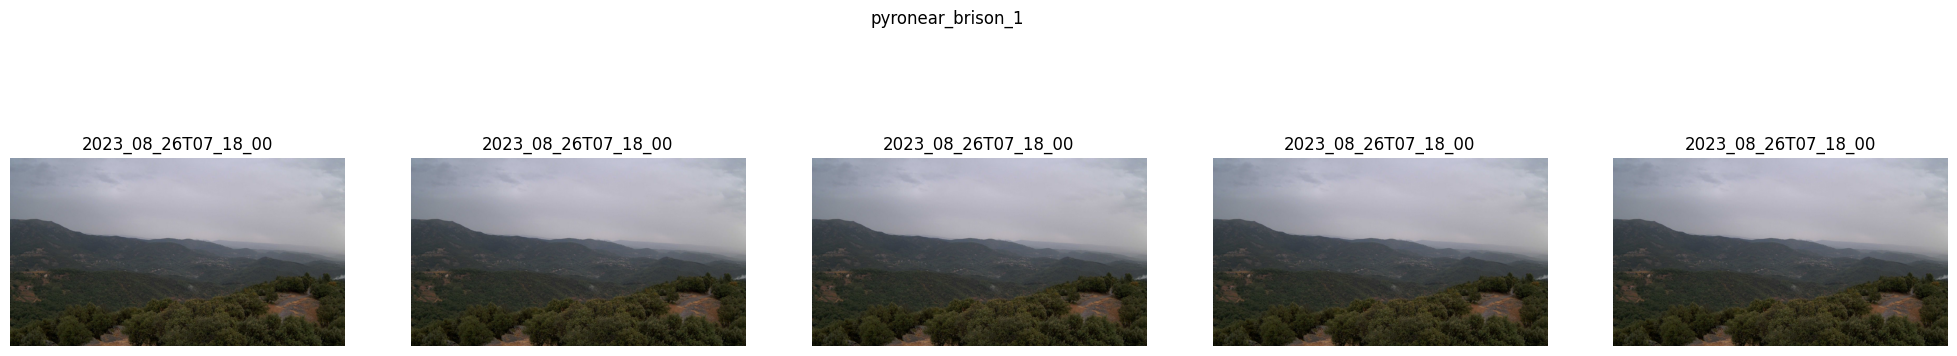

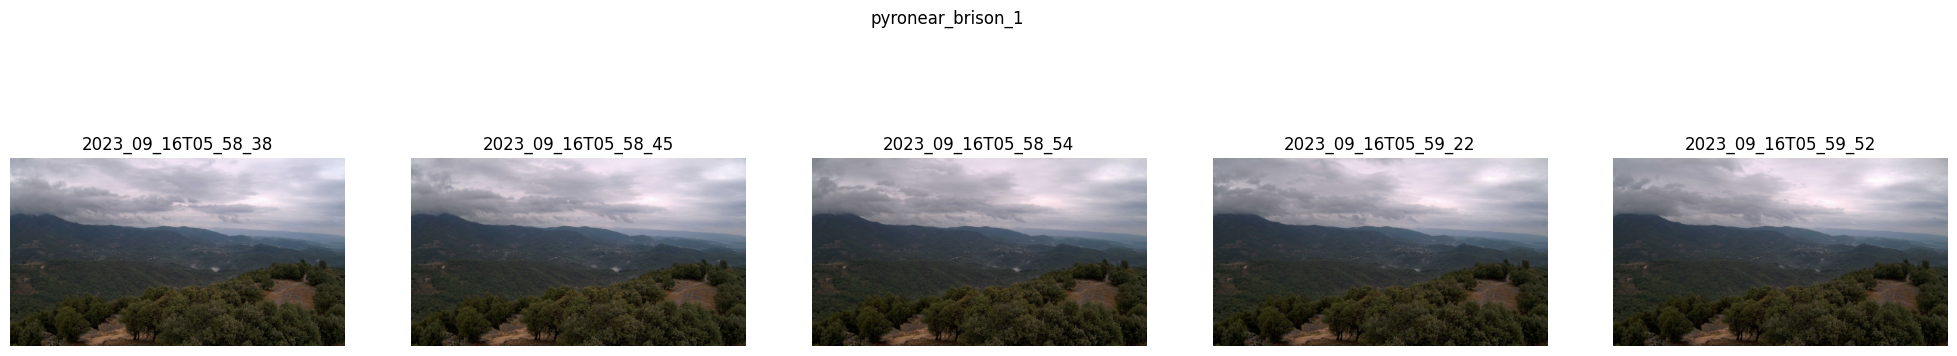

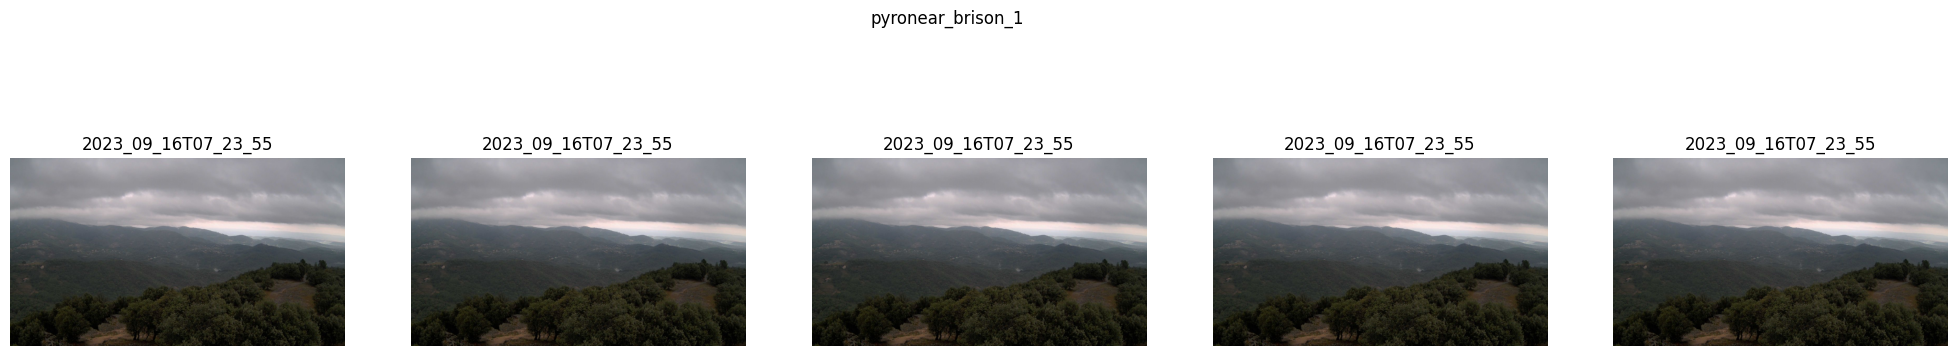

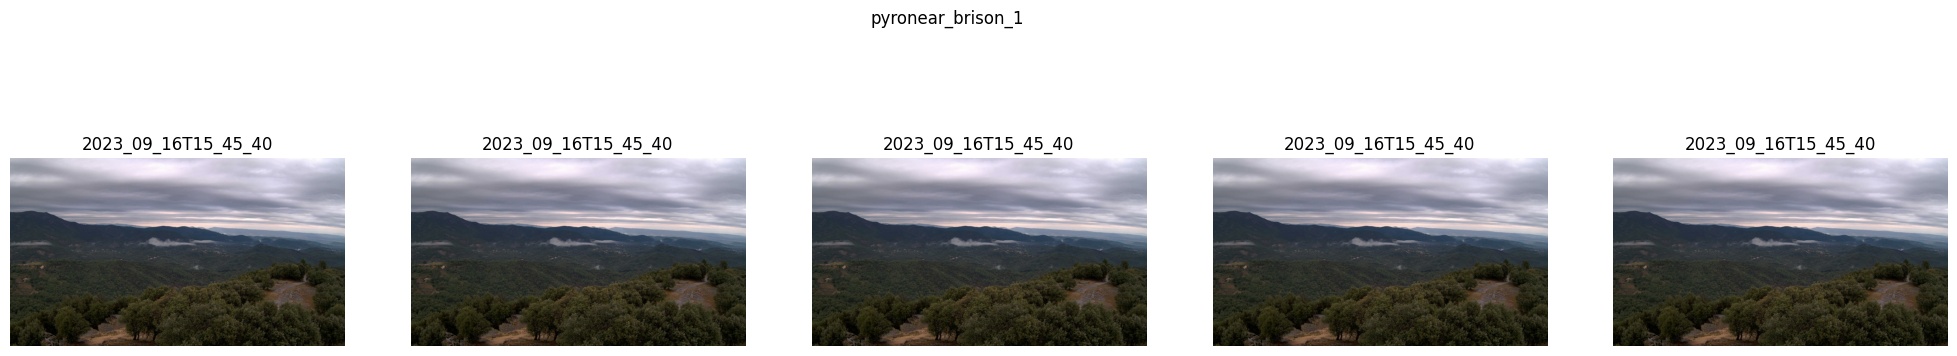

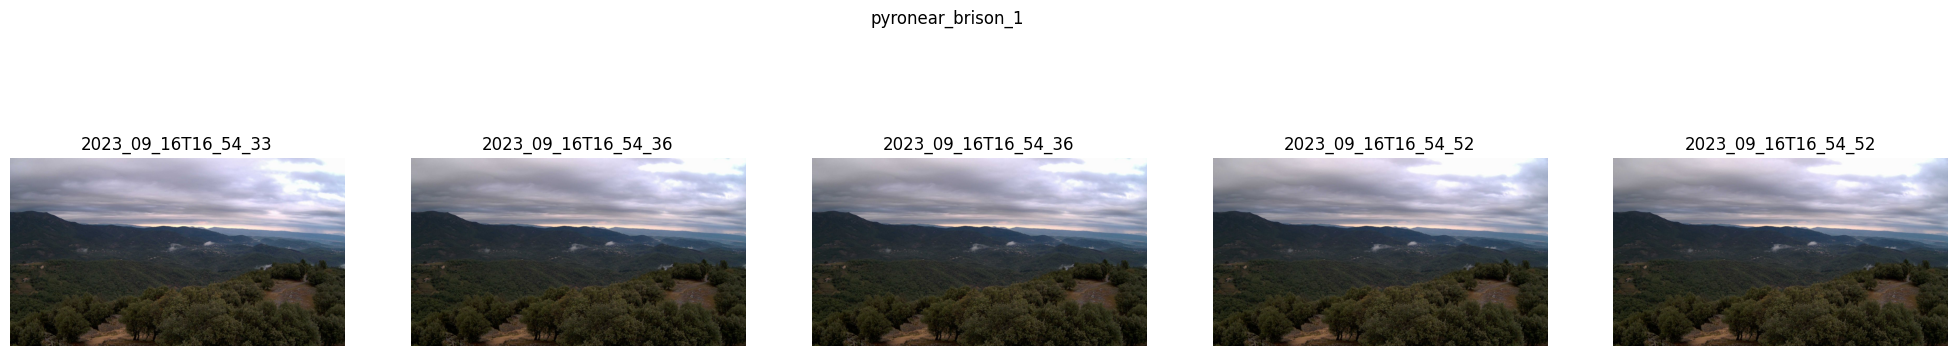

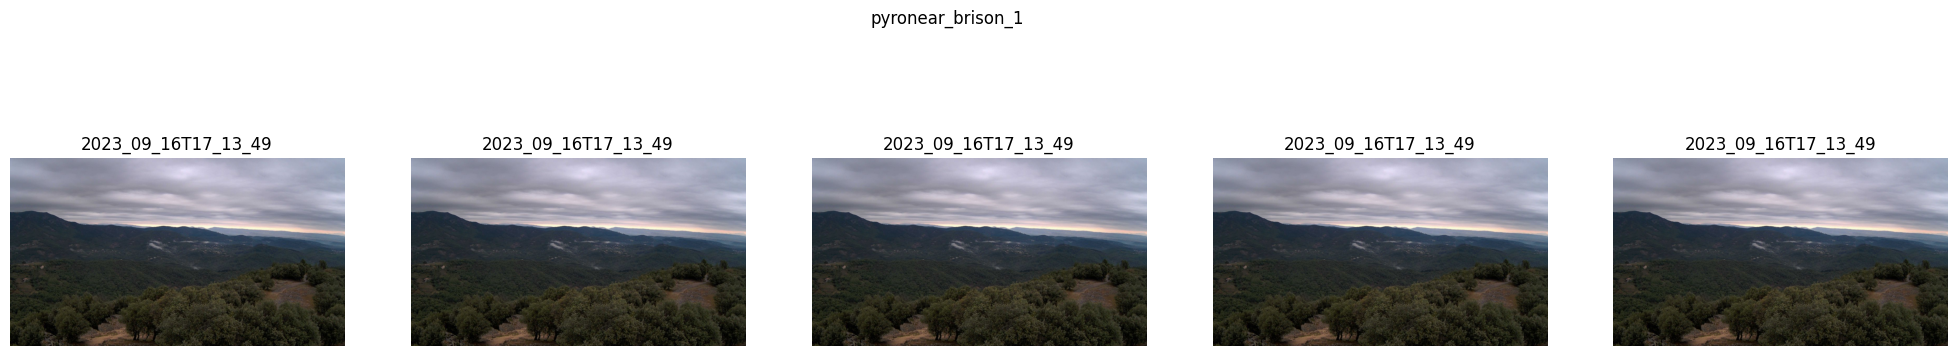

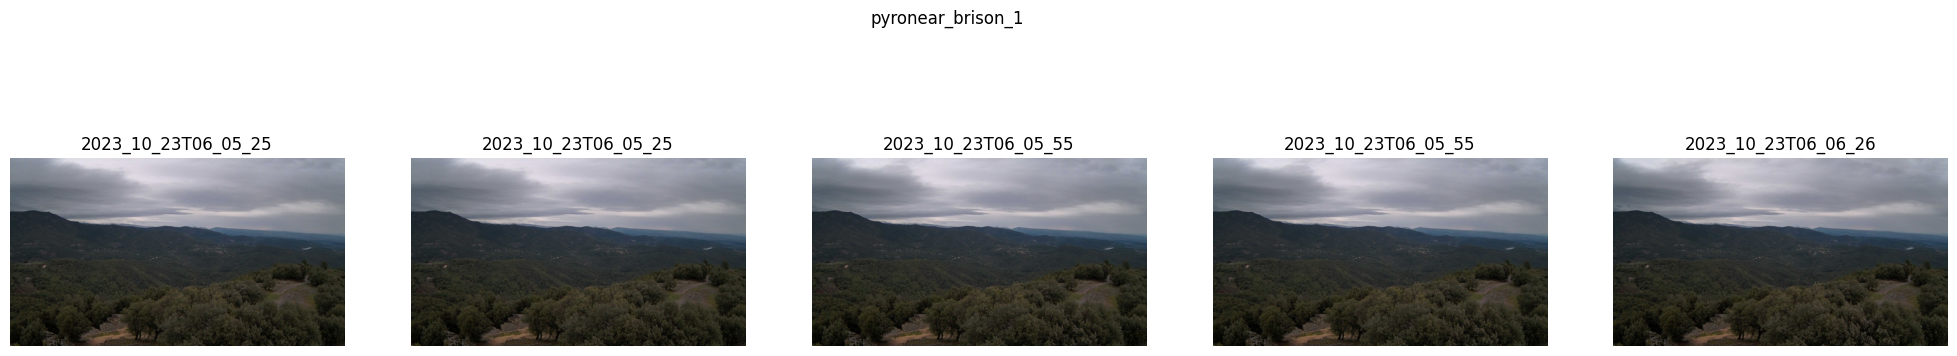

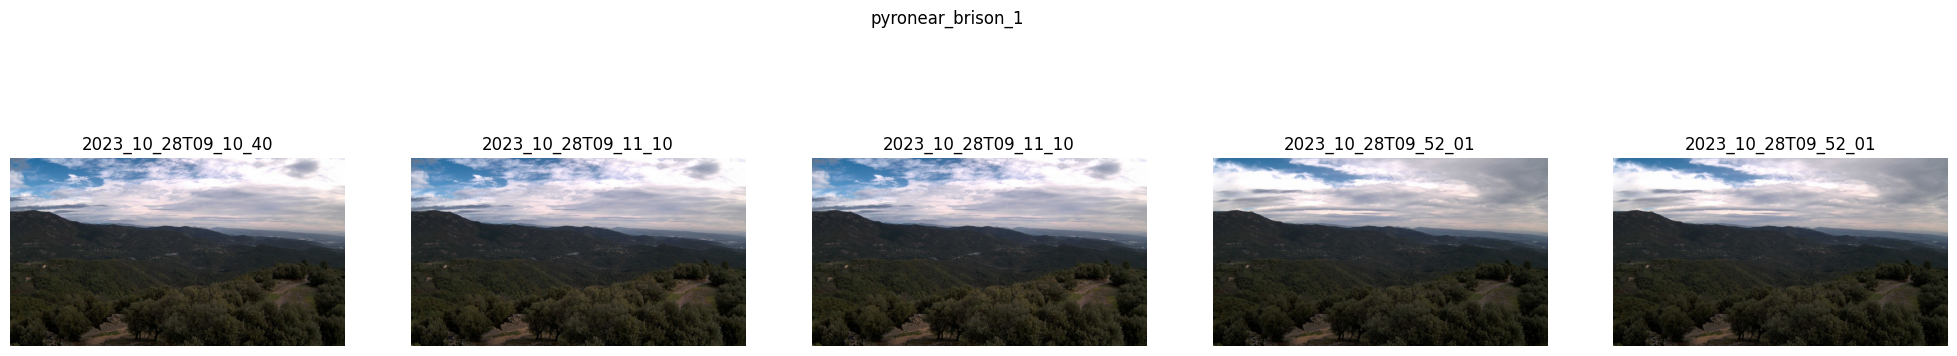

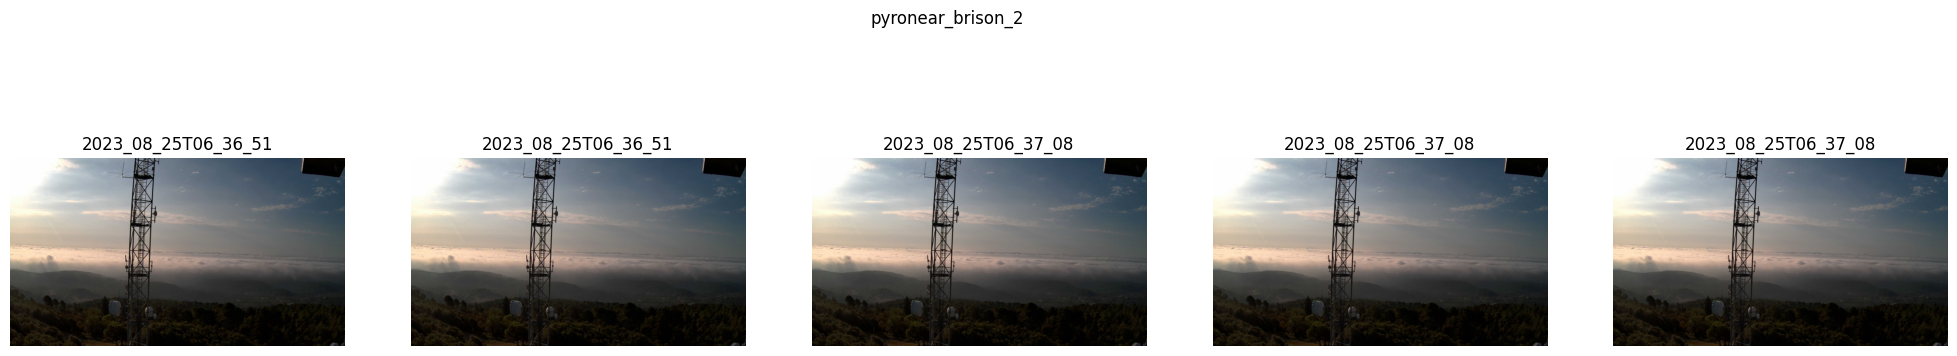

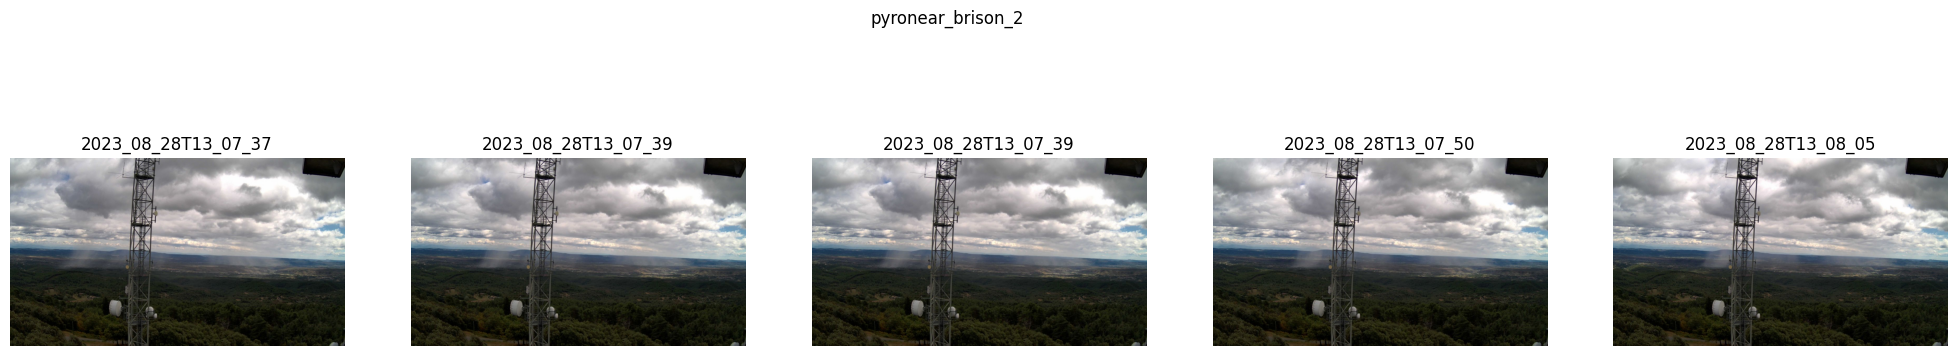

In [24]:
# Save in PDF
imshow_all_series(X_visu, X_names, sequence_length, pdf_path=f"output_test_pdf_bis_{gt_pred_class_label}.pdf")
